# Régression multiple avec plusieurs variables - CO₂ et masse, puissance et consommation des véhicules

Deuxième notebook du cours *Machine Learning Specialization* (DeepLearning.AI, cours 1 — semaine 2), appliqué au jeu de données ADEME des émissions des véhicules commercialisés en France.

Dans le premier notebook, consacré à la régression linéaire simple, j'ai trouvé qu'une seule variable, la masse, ne suffisait pas à prédire le CO₂ émit par un véhicule.

Dans ce notebook, je vais utiliser plusieurs variables pour tenter de prédire les émissions de CO₂ des véhicules.

## Choix des variables

Le choix des variables est une décision cruciale. J'ai 26 colonnes. Certaines sont des identifiants, certaines sont redondantes, certaines n'ont de sens que pour une motorisation.

### Le problème avec `conso_mixte`

Dans mon analyse exploratoire, j'avais trouvé que la corrélation entre la consommation et le CO₂ étaient était de 0.976. Elle pose une vraie question : *Le CO₂ est il calculé à partir de la consommation?.*

Vérifions:


count    12675.000000
mean        26.147373
std          0.261388
min         24.761905
25%         26.031746
50%         26.190476
75%         26.304348
max         27.500000
dtype: float64
count    6934.000000
mean       23.265957
std         0.224405
min        20.952381
25%        23.164557
50%        23.272727
75%        23.376623
max        28.181818
dtype: float64


Text(0, 0.5, 'CO₂ (g/km)')

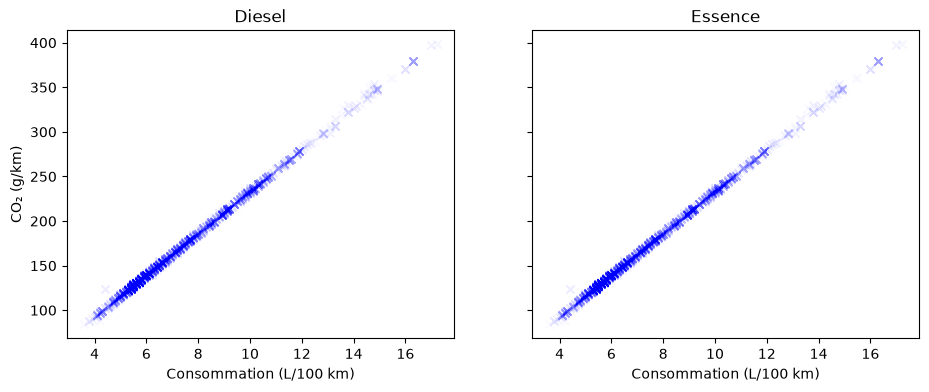

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


df = pd.read_csv("data/vehicules.csv", sep=";", encoding="latin-1")
obj = df.select_dtypes(include="str").columns
df[obj] = df[obj].apply(lambda s: s.str.strip())

MOTORISATIONS = {"GO":"Diesel", "ES":"Essence"}


for code,_ in MOTORISATIONS.items():
    cs = df[df["energ"] == code][["conso_mixte", "co2_mixte"]].dropna()
    print((cs["co2_mixte"] / cs["conso_mixte"]).describe())

fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)

for ax, nom in zip(axes, MOTORISATIONS):
    ax.scatter(cs["conso_mixte"], cs["co2_mixte"], c="b", marker="x", alpha=0.01)
    ax.set_xlabel("Consommation (L/100 km)")
    ax.set_title(MOTORISATIONS.get(nom))

axes[0].set_ylabel("CO₂ (g/km)")

Le résultat obtenu pour les véhicules `Diesel`et `Essence` est un rapport quasi constant autour de 26.14 pour le disel. Autrement dit, `CO₂ ≈ 26.1 * conso`. Et pour 23.26 pour l'essence. La consommation contient donc l'information sur le CO₂ => ce qui implique très probablement une fuite de données.

Pour le choix des variables, je vais donc exclure `conso_mixte`, `conso_urb_93` et `conso_exurb`. Je vais gardais uniquement les variables qui décrivent le véhicule (ce qu'un constructeur connaît au moment de la conception) plutôt que son comportement mesuré : `masse_ordma_min`, `puiss_max`, `puiss_admin`, et plus tard le type de boîte ou l'énergie.

Dans la suite du notebook, analysons les deux modèles suivants:
1. Modèle A : masse + puissance → R² « honnête »
2. Modèle B : avec conso_mixte → R² proche de 1

Si la `conso`est effectivement une fuite de données, dans les coefficients du modèle B, la masse et la puissance auront quasiment disparu.

## Partie I - Régression multiple sur les véhicules diesel

In [2]:
cols = ["masse_ordma_min", "puiss_max", "conso_mixte", "co2_mixte"]
d = df[df["energ"] == "GO"][cols].dropna()

y = d["co2_mixte"].values
X_a = d[["masse_ordma_min", "puiss_max"]].values          # modèle A
X_b = d[["masse_ordma_min", "puiss_max", "conso_mixte"]].values  # modèle B

for nom, X, noms_var in [("A", X_a, ["masse", "puissance"]),
                         ("B", X_b, ["masse", "puissance", "conso"])]:
    m = LinearRegression().fit(X, y)
    print(f"\nModèle {nom} — R² = {r2_score(y, m.predict(X)):.3f}  "
          f"MAE = {mean_absolute_error(y, m.predict(X)):.1f} g/km")
    for v, c in zip(noms_var, m.coef_):
        print(f"   {v:12s} {c:8.3f}")



Modèle A — R² = 0.806  MAE = 11.4 g/km
   masse           0.084
   puissance      -0.011

Modèle B — R² = 0.999  MAE = 1.0 g/km
   masse          -0.001
   puissance       0.002
   conso          26.568


### Comparaison des modèles A et B

Le R² du modèle du modèle B est supérieur à celui du modèle A et presque égale à 1. Les coefficients de la masse de A est supérieur à celui de B. Dans le modèle B, les deux caractèristiques du véhicule, masse et puissance, ont littéralement disparu — leurs coefficients sont mille fois plus petits que celui de la consommation.

Le coefficient de conso `26,568` n'est pas un paramètre appris, dans la plage que l'on avait trouvé plus haut pour `conso_mixte`:
moyenne = 26,15   écart-type = 0,26   (min 24,8, max 27,5)

Elle confirme que `conso_mixte` est bien une constante physique : le facteur d'émission du gazole. Le modèle a retrouvé tout seul que brûler un litre de gazole émet environ 26,5 g de CO₂ par litre-au-100km. Le R² de 0,999 et la MAE de 1,0 g/km ne mesurent pas une capacité de prédiction, ils mesurent la précision de l'arrondi dans le fichier source.
**Un modèle qui a « appris » une identité comptable n'a rien appris du tout.**

A noter également que le R² de A (`0,806`) est quasi identique à celui de ta régression simple sur la masse seule(`0,805`). **Ajouter la puissance n'apporte rien chez les diesels** — ça contredit ton hypothèse de départ.

#### Un résultat innatendu dans le modèle A

Dans le modèle 1, le coéfficient de la puissance est **négatif** (`-0,011`).
Littéralement, ça dit « à masse égale, plus le véhicule est puissant, moins il émet ». Physiquement absurde.

Ceci peu peut-être s'expliquer de deux manières: 
- Il  y a une multicolinéarité entre la masse et la puissance. De ce fait, le modèle peine à séparer leurs effets et compense l'un par l'autre.
- Un vrai effet conditionnel: à masse donnée, les diesels puissants sont peut-être des motorisations plus modernes et plus efficientes.

In [3]:
# 1. La corrélation entre les deux variables
print(d[["masse_ordma_min", "puiss_max"]].corr())

# 2. Comparer masse seule vs masse+puissance, proprement
for noms in [["masse_ordma_min"], ["puiss_max"], ["masse_ordma_min", "puiss_max"]]:
    m = LinearRegression().fit(d[noms].values, y)
    print(noms, f"R² = {r2_score(y, m.predict(d[noms].values)):.4f}")
    

                 masse_ordma_min  puiss_max
masse_ordma_min         1.000000   0.218659
puiss_max               0.218659   1.000000
['masse_ordma_min'] R² = 0.8055
['puiss_max'] R² = 0.0349
['masse_ordma_min', 'puiss_max'] R² = 0.8056


**La puissance n'apporte rien — et ce n'est pas la multicolinéarité**

Le gain est de **0,0001** pour le R² masse vs masse + puissance. Autrement dit : rien.
Et la corrélation masse/puissance n'est que de 0,22 — bien trop faible pour parler de multicolinéarité. Mon hypothèse n°1 n'est pas valable.

L'explication est ailleurs, et elle est plus simple : chez les diesels, la puissance seule explique 3,5 % de la variation du CO₂ (`R² = 0.0349`). Elle n'a quasiment pas d'information à apporter, et le peu qu'elle a est déjà contenu dans la masse. Le coefficient négatif de -0,011 n'est donc pas un effet réel : c'est un ajustement de bruit, sur une variable qui ne sert à rien. Je ne vais pas chercher à l'interpréter.

## Partie II - Régression multiple sur les véhicules essence

In [4]:
d = df[df["energ"] == "ES"][cols].dropna()

y = d["co2_mixte"].values
X_a = d[["masse_ordma_min", "puiss_max"]].values          # modèle A
X_b = d[["masse_ordma_min", "puiss_max", "conso_mixte"]].values  # modèle B

for nom, X, noms_var in [("A", X_a, ["masse", "puissance"]),
                         ("B", X_b, ["masse", "puissance", "conso"])]:
    m = LinearRegression().fit(X, y)
    print(f"\nModèle {nom} — R² = {r2_score(y, m.predict(X)):.3f}  "
          f"MAE = {mean_absolute_error(y, m.predict(X)):.1f} g/km")
    for v, c in zip(noms_var, m.coef_):
        print(f"   {v:12s} {c:8.3f}")


Modèle A — R² = 0.785  MAE = 17.2 g/km
   masse           0.051
   puissance       0.307

Modèle B — R² = 0.999  MAE = 0.9 g/km
   masse           0.000
   puissance       0.002
   conso          23.360


In [5]:
# 1. La corrélation entre les deux variables
print(d[["masse_ordma_min", "puiss_max"]].corr())

# 2. Comparer masse seule vs masse+puissance, proprement
for noms in [["masse_ordma_min"], ["puiss_max"], ["masse_ordma_min", "puiss_max"]]:
    m = LinearRegression().fit(d[noms].values, y)
    print(noms, f"R² = {r2_score(y, m.predict(d[noms].values)):.4f}")

                 masse_ordma_min  puiss_max
masse_ordma_min         1.000000   0.770936
puiss_max               0.770936   1.000000
['masse_ordma_min'] R² = 0.6210
['puiss_max'] R² = 0.7485
['masse_ordma_min', 'puiss_max'] R² = 0.7846


### **La puissance compte vraiment chez l'essence**

Chez l'essence, la puissance explique **75 %** de la variation à elle seule, contre 3,5 % chez le diesel. Et l'ajout apporte un gain réel : +0,164 contre +0,0001. Son coefficient est positif (`0,307`), physiquement cohérent.

Pourquoi cet écart ? La population essence est bien plus hétérogène — de la citadine de 900 kg à la Lamborghini de 545 kW. La puissance y discrimine fortement. Le diesel, concentré sur berlines et utilitaires, varie surtout en masse.

C'est un résultat que mon analyse exploratoire ne pouvait pas donner : il fallait un modèle pour le voir.

**Une nuance à ne pas manquer**

Ici, la corrélation masse/puissance vaut **0,77** (contre 0,22 chez le diesel). Cette fois, la multicolinéarité est réelle : les deux variables se recouvrent largement. D'où le fait que 0,621 + 0,749 ne donne pas 1,37 mais 0,785 — l'information est partagée, pas additive.

**La fuite est confirmée**

`conso = 23,360` chez l'essence contre `26,568` chez le diesel. Un « paramètre appris » qui change de valeur selon le carburant — c'est bien un facteur d'émission physique, pas un apprentissage.

## Partie III - Feature Engineering & Régression polynomiale

In [6]:
d["ratio_p_m"] = d["puiss_max"] / d["masse_ordma_min"]

for noms in [["masse_ordma_min", "puiss_max"],
             ["masse_ordma_min", "puiss_max", "ratio_p_m"],
             ["masse_ordma_min", "ratio_p_m"]]:
    m = LinearRegression().fit(d[noms].values, y)
    print(noms, f"R² = {r2_score(y, m.predict(d[noms].values)):.4f}")

['masse_ordma_min', 'puiss_max'] R² = 0.7846
['masse_ordma_min', 'puiss_max', 'ratio_p_m'] R² = 0.7866
['masse_ordma_min', 'ratio_p_m'] R² = 0.7855


**Le ratio n'apporte presque rien**

+0,002 en ajoutant `ratio_p_m`. C'est du bruit. Mon intuition — « le ratio capture le caractère sportif » — n'est pas confirmée par les données.
Bon à retenir : **créer une variable ne garantit rien.**

In [7]:
d["puiss_max²"] = d["puiss_max"]**2

for noms in [["masse_ordma_min", "puiss_max"],
             ["masse_ordma_min", "puiss_max", "puiss_max²"],
             ["masse_ordma_min", "puiss_max²"]]:
    m = LinearRegression().fit(d[noms].values, y)
    print(noms, f"R² = {r2_score(y, m.predict(d[noms].values)):.4f}")

['masse_ordma_min', 'puiss_max'] R² = 0.7846
['masse_ordma_min', 'puiss_max', 'puiss_max²'] R² = 0.7965
['masse_ordma_min', 'puiss_max²'] R² = 0.7965


**Le terme quadratique apporte un peu**

+0,012 avec `puiss_max²`. Modeste mais réel, et cohérent avec la physique : les émissions croissent plus vite que linéairement avec la puissance.

**Un détail intéressant que j'ai remarqué**

masse + puissance + puissance²   R² = 0,7965
masse + puissance²               R² = 0,7965

**Exactement le même score.** Une fois le terme quadratique présent, la puissance linéaire ne sert plus à rien — `puiss_max²` contient déjà l'essentiel de son information (leur corrélation doit être très élevée). Le modèle à deux variables fait aussi bien que celui à trois.

In [8]:
X0 = d[["masse_ordma_min", "puiss_max"]].values
X1 = d[["masse_ordma_min", "puiss_max²"]].values

m0 = LinearRegression().fit(X0, y)
m1 = LinearRegression().fit(X1, y)

fit0 = m0.predict(X0)
fit1 = m1.predict(X1)

d["res0"] = y - fit0
d["res1"] = y - fit1

print(d[["res0","res1"]].abs().max())
print(d[["res0","res1"]].abs().describe())

res0    160.609033
res1    167.152146
dtype: float64
              res0         res1
count  6934.000000  6934.000000
mean     17.151142    16.536428
std      18.415629    18.020938
min       0.003193     0.001633
25%       6.439505     6.006480
50%      12.664534    12.002246
75%      21.538355    20.205508
max     160.609033   167.152146


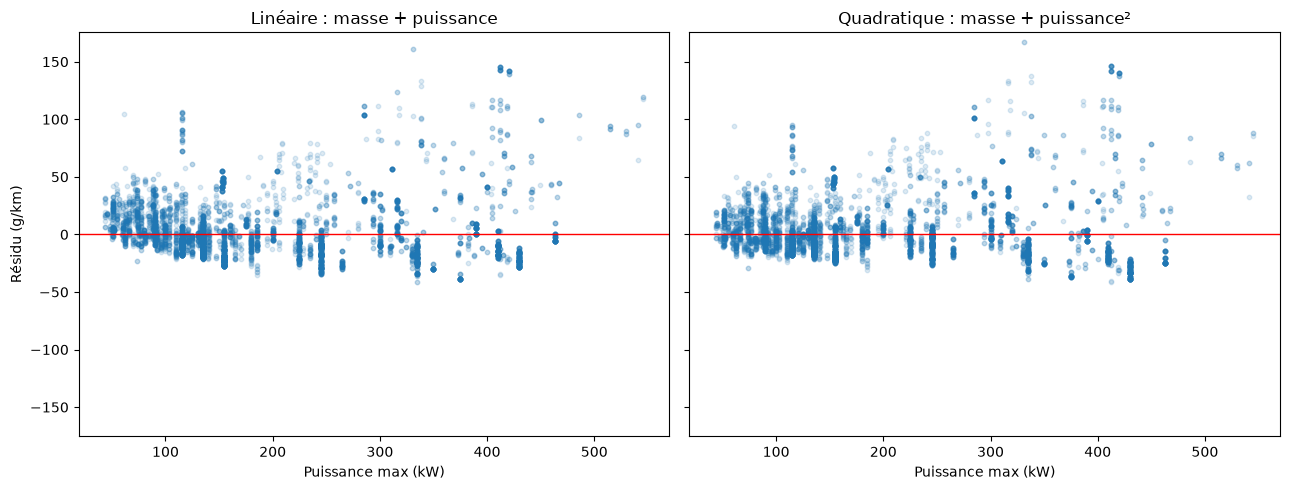

In [9]:
lim = d[["res0", "res1"]].abs().max().max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, col, titre in zip(axes, ["res0", "res1"],
                          ["Linéaire : masse + puissance",
                           "Quadratique : masse + puissance²"]):
    ax.scatter(d["puiss_max"], d[col], alpha=0.15, s=10, c="tab:blue")
    ax.axhline(0, c="r", lw=1)
    ax.set_title(titre)
    ax.set(xlabel= "Puissance max (kW)", ylim=(-lim, lim))
axes[0].set_ylabel("Résidu (g/km)")
plt.tight_layout()
plt.show()

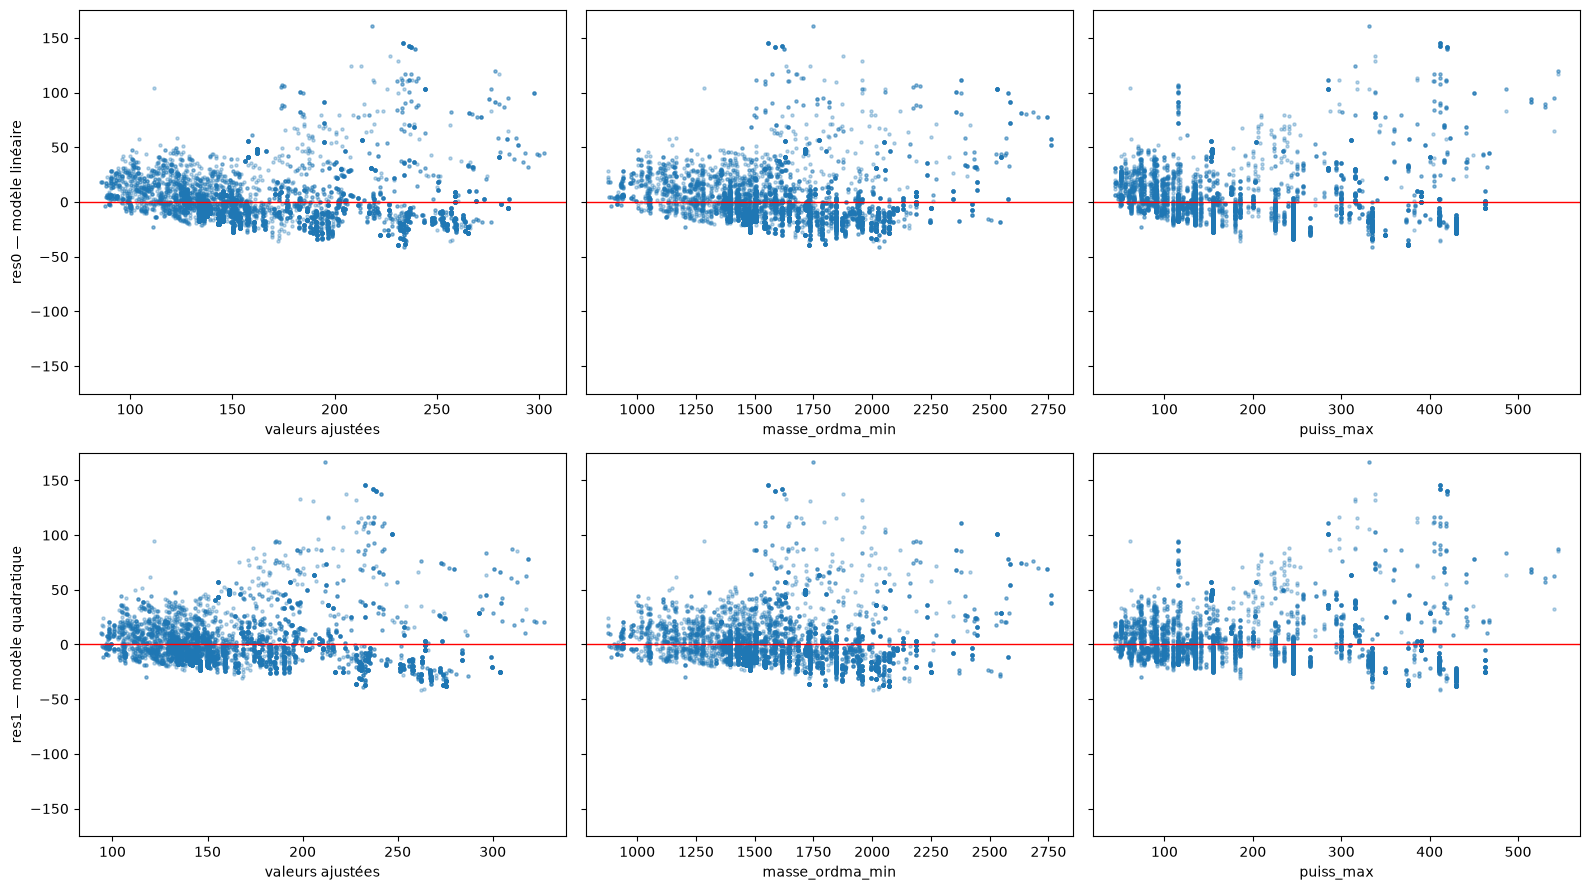

In [10]:
lim = d[["res0", "res1"]].abs().max().max() * 1.05

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

modeles = [("res0", fit0, "linéaire"), ("res1", fit1, "quadratique")]

for i, (col, fitted, nom_modele) in enumerate(modeles):
    abscisses = [
        (fitted, "valeurs ajustées"),
        (d["masse_ordma_min"], "masse_ordma_min"),
        (d["puiss_max"], "puiss_max"),
    ]
    for j, (x, nom_x) in enumerate(abscisses):
        axes[i, j].scatter(x, d[col], s=5, alpha=0.3)
        axes[i, j].axhline(0, color="red", lw=1)
        axes[i, j].set(xlabel=nom_x, ylim=(-lim, lim))
    axes[i, 0].set_ylabel(f"{col} — modèle {nom_modele}")

plt.tight_layout()
plt.show()

## Ce que je retiens de la semaine 2

**Sur les variables.** Ajouter la puissance n'améliore pas la prédiction chez les diesels. La seule variable qui « améliore » le modèle le rend inutilisable. 

**Sur les modèles.** Chez l'essence, la puissance y est très importante et très corrélée à la masse - Conséquence : les coefficients du modèle essence sont instables. Si on retire une variable, l'autre bougera beaucoup.